# Checkpoint 2: FER-2013 Emotion Recognition

**Course:** CSE 676 Deep Learning  
**Project:** Emotion Recognition from Facial Expressions  
**Team:** Anirudh Ramesh and Rohan Marar  
**Dataset:** FER-2013

This notebook contains the Checkpoint 2 implementation for our FER-2013 emotion recognition project. It includes dataset checks, preprocessing, a baseline CNN, and ResNet-18 transfer-learning experiments. The saved outputs shown below are from the Colab run used for this checkpoint.


## 1. Setup and Imports

### Colab Setup

The first cells mount Google Drive, create output folders, and download FER-2013 with `kagglehub`. If the notebook is stored in a different Drive folder, only `BASE_DIR` should need to change.


In [ ]:
# Mount Drive and set project paths
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os

# Change this only if your notebook is inside a different Drive folder
BASE_DIR = Path('/content/drive/MyDrive/emotion_project')

# Create the folder if it does not exist
BASE_DIR.mkdir(parents=True, exist_ok=True)

# Outputs will persist in Drive
OUTPUTS_DIR = BASE_DIR / 'outputs'
CHECKPOINT_DIR = OUTPUTS_DIR / 'checkpoints'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
METRICS_DIR = OUTPUTS_DIR / 'metrics'

for folder in [OUTPUTS_DIR, CHECKPOINT_DIR, FIGURES_DIR, METRICS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/emotion_project
OUTPUTS_DIR: /content/drive/MyDrive/emotion_project/outputs


In [ ]:
# Install kagglehub and download FER-2013
!pip -q install kagglehub

import kagglehub
from pathlib import Path

LOCAL_DATA_ROOT = Path('/content/data')
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

download_path = kagglehub.dataset_download(
    "msambare/fer2013",
    output_dir=str(LOCAL_DATA_ROOT)
)

DATA_DIR = Path(download_path)

# Handle one extra nested folder if needed
if not (DATA_DIR / 'train').exists() and not (DATA_DIR / 'test').exists():
    subdirs = [p for p in DATA_DIR.iterdir() if p.is_dir()]
    if len(subdirs) == 1:
        DATA_DIR = subdirs[0]

print("DATA_DIR:", DATA_DIR)
print("Contents:", sorted([p.name for p in DATA_DIR.iterdir()])[:20])

Using Colab cache for faster access to the 'fer2013' dataset.
DATA_DIR: /kaggle/input/fer2013
Contents: ['test', 'train']


In [ ]:
# Imports
import os
import json
import random
import warnings
from pathlib import Path
from collections import Counter
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings('ignore')

# Reproducibility
def set_seed(seed=42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

# Basic config
BASELINE_BS = 128
TL_BS = 64
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

Device: cuda
GPU: NVIDIA L4
CUDA version: 12.8


## 2. Dataset Loading

The dataset is expected in the usual FER-2013 folder layout:

```
data/fer2013/
├── train/
│   ├── angry/
│   ├── disgust/
│   ├── fear/
│   ├── happy/
│   ├── neutral/
│   ├── sad/
│   └── surprise/
└── test/
    └── ... same classes ...
```

If a validation folder is not available, the notebook creates a validation split from the training set using a fixed seed.


In [ ]:
# Find dataset folders
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

def discover_dataset(data_dir):
    """Inspect the dataset folder structure and report what we find."""
    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(
            f"\n{'='*60}\n"
            f"  Dataset NOT found at:\n"
            f"    {data_dir.resolve()}\n\n"
            f"  Please download FER-2013 and organize it as:\n"
            f"    {data_dir}/train/<emotion>/*.jpg\n"
            f"    {data_dir}/test/<emotion>/*.jpg\n"
            f"    {data_dir}/val/<emotion>/*.jpg   (optional)\n"
            f"{'='*60}"
        )

    splits = {}
    for name in ['train', 'test', 'val', 'validation']:
        sp = data_dir / name
        if sp.is_dir():
            classes = sorted([d.name for d in sp.iterdir() if d.is_dir()])
            counts = {
                c: len([f for f in (sp / c).iterdir()
                        if f.suffix.lower() in IMAGE_EXTS])
                for c in classes
            }
            key = 'val' if name == 'validation' else name
            splits[key] = {'path': sp, 'classes': classes, 'counts': counts}

    if not splits or 'train' not in splits:
        raise FileNotFoundError(
            f"\n{'='*60}\n"
            f"  Expected at least a 'train/' folder inside:\n"
            f"    {data_dir.resolve()}\n"
            f"{'='*60}"
        )

    return splits

# Inspect dataset
splits_info = discover_dataset(DATA_DIR)

print("Detected dataset structure:")
for name, info in splits_info.items():
    total = sum(info['counts'].values())
    print(f"  {name:>5s}: {total:>6d} images  |  {len(info['classes'])} classes")

CLASS_NAMES = splits_info['train']['classes']
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

HAS_VAL = 'val' in splits_info
if not HAS_VAL:
    print("\n⚠  No validation split detected — will create one from training data (80/20).")

Detected dataset structure:
  train:  28709 images  |  7 classes
   test:   7178 images  |  7 classes

Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

⚠  No validation split detected — will create one from training data (80/20).


## 3. EDA and Class Distribution

Before training, we check the class distribution and view a few sample images from each class.


### Class Distribution

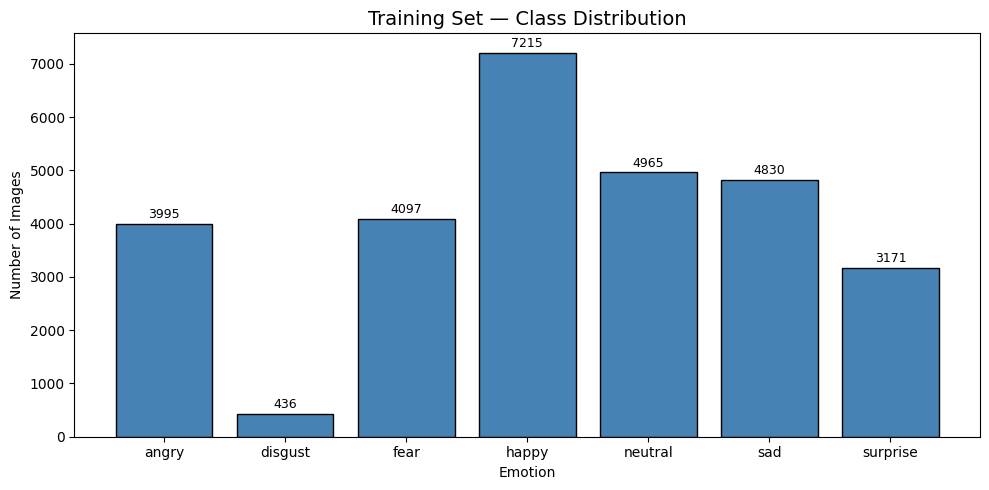

Class proportions:
       angry:  3995  (13.9%)
     disgust:   436  (1.5%)
        fear:  4097  (14.3%)
       happy:  7215  (25.1%)
     neutral:  4965  (17.3%)
         sad:  4830  (16.8%)
    surprise:  3171  (11.0%)

Imbalance ratio (max / min): 16.5x  (happy vs disgust)
→ Noticeable class imbalance — will use class-weighted loss during training.


In [ ]:
# Plot training class distribution
train_counts = splits_info['train']['counts']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(train_counts.keys(), train_counts.values(),
              color='steelblue', edgecolor='black')
ax.set_title('Training Set — Class Distribution', fontsize=14)
ax.set_xlabel('Emotion')
ax.set_ylabel('Number of Images')

for bar, count in zip(bars, train_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution_train.png', dpi=150, bbox_inches='tight')
plt.show()

# Print imbalance summary
total = sum(train_counts.values())
print("Class proportions:")
for cls, cnt in train_counts.items():
    print(f"  {cls:>10s}: {cnt:>5d}  ({100 * cnt / total:.1f}%)")

min_cls = min(train_counts, key=train_counts.get)
max_cls = max(train_counts, key=train_counts.get)
ratio = train_counts[max_cls] / train_counts[min_cls]
print(f"\nImbalance ratio (max / min): {ratio:.1f}x  ({max_cls} vs {min_cls})")
if ratio > 3:
    print("→ Noticeable class imbalance — will use class-weighted loss during training.")

### Sample Images

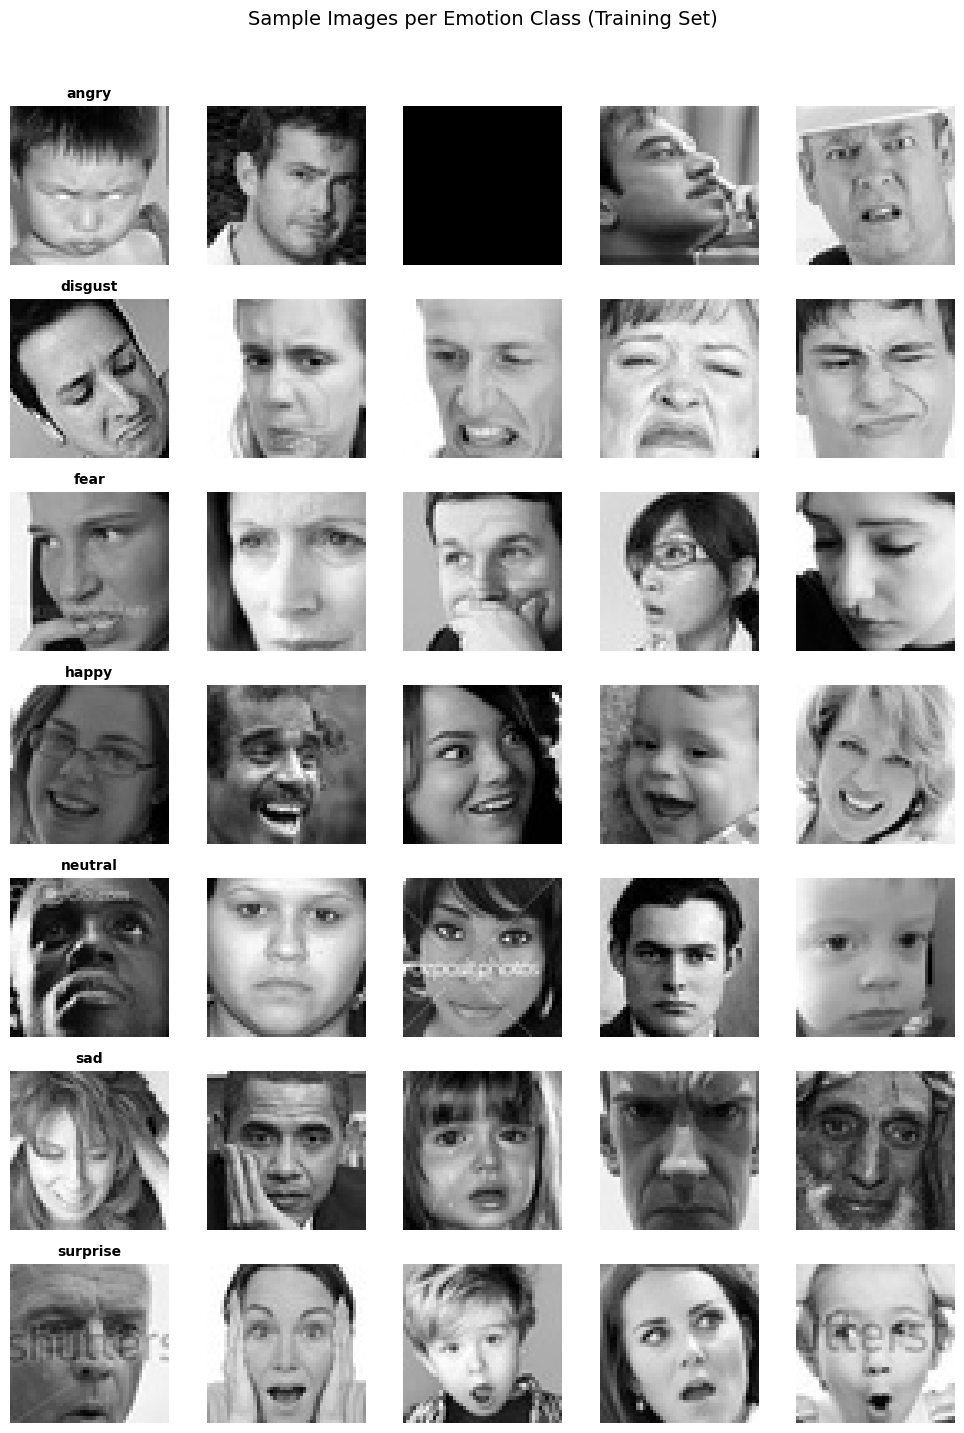

In [ ]:
# Show sample images by class
def show_sample_grid(data_path, class_names, n_per_class=5):
    """Display a grid with one row per emotion class."""
    n_rows = len(class_names)
    fig, axes = plt.subplots(n_rows, n_per_class,
                             figsize=(n_per_class * 2, n_rows * 2))

    for i, cls in enumerate(class_names):
        cls_dir = data_path / cls
        imgs = sorted([f for f in cls_dir.iterdir()
                       if f.suffix.lower() in IMAGE_EXTS])[:n_per_class]
        for j in range(n_per_class):
            ax = axes[i][j]
            if j < len(imgs):
                img = Image.open(imgs[j])
                ax.imshow(img, cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(cls, fontsize=10, fontweight='bold')

    plt.suptitle('Sample Images per Emotion Class (Training Set)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sample_images_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_grid(splits_info['train']['path'], CLASS_NAMES)

### Image Properties Check

In [ ]:
# Check sample image properties
sample_cls = CLASS_NAMES[0]
sample_dir = splits_info['train']['path'] / sample_cls
sample_files = sorted([f for f in sample_dir.iterdir()
                       if f.suffix.lower() in IMAGE_EXTS])[:10]

sizes = set()
modes = set()
for fp in sample_files:
    img = Image.open(fp)
    sizes.add(img.size)
    modes.add(img.mode)

print("Image property check (first 10 samples):")
print(f"  Unique sizes : {sizes}")
print(f"  Color modes  : {modes}")

if len(sizes) == 1:
    w, h = list(sizes)[0]
    print(f"  → All sampled images are {w}×{h}")
if 'L' in modes:
    print("  → Images are grayscale (1 channel)")
elif 'RGB' in modes:
    print("  → Images are RGB (3 channels)")

Image property check (first 10 samples):
  Unique sizes : {(48, 48)}
  Color modes  : {'L'}
  → All sampled images are 48×48
  → Images are grayscale (1 channel)


## 4. Preprocessing and Augmentation

Two preprocessing pipelines are used. The baseline CNN keeps the FER-2013 images at 48x48 grayscale. ResNet-18 uses 224x224 three-channel inputs with ImageNet normalization.


### Baseline CNN Transforms

In [ ]:
# Baseline CNN transforms
IMG_SIZE = 48  # FER-2013 native resolution

baseline_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

baseline_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

print("Baseline transforms defined (grayscale 48×48).")

Baseline transforms defined (grayscale 48×48).


### Transfer Learning Transforms (ResNet-18)

In [ ]:
# Transfer learning transforms
TL_IMG_SIZE    = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

tl_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # grayscale → 3-channel
    transforms.Resize((TL_IMG_SIZE, TL_IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

tl_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((TL_IMG_SIZE, TL_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transfer learning transforms defined (RGB 224×224, ImageNet normalization).")

Transfer learning transforms defined (RGB 224×224, ImageNet normalization).


## 5. Dataset and DataLoader Setup

`ImageFolder` reads the class folders directly. The same split logic is reused across the baseline and ResNet experiments so the comparison is fair.


In [ ]:
# Get labels from datasets
def get_targets(dataset):
    """Return a list of integer labels for a Dataset or Subset."""
    if isinstance(dataset, Subset):
        return [dataset.dataset.targets[i] for i in dataset.indices]
    elif hasattr(dataset, 'targets'):
        return dataset.targets
    else:
        # Slow fallback
        return [y for _, y in dataset]


def create_datasets_and_loaders(train_transform, test_transform,
                                batch_size=64, val_split=0.2, num_workers=2):
    """Build train / val / test datasets and DataLoaders.

    If a validation folder exists on disk it is used directly.
    Otherwise 'val_split' fraction is held out from the training set.
    """
    train_path = splits_info['train']['path']
    test_path  = splits_info['test']['path']

    test_ds = datasets.ImageFolder(test_path, transform=test_transform)

    if HAS_VAL:
        val_path = splits_info['val']['path']
        train_ds = datasets.ImageFolder(train_path, transform=train_transform)
        val_ds   = datasets.ImageFolder(val_path,   transform=test_transform)
    else:
        # Two ImageFolder objects: one with augmentation, one without
        full_train_aug   = datasets.ImageFolder(train_path, transform=train_transform)
        full_train_clean = datasets.ImageFolder(train_path, transform=test_transform)

        n = len(full_train_aug)
        indices = list(range(n))
        set_seed(42)
        random.shuffle(indices)

        split_idx = int(n * (1 - val_split))
        train_indices = indices[:split_idx]
        val_indices   = indices[split_idx:]

        train_ds = Subset(full_train_aug,   train_indices)
        val_ds   = Subset(full_train_clean, val_indices)

    pin = (device.type == 'cuda')
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

In [ ]:
# Build baseline dataloaders
(baseline_train_ds, baseline_val_ds, baseline_test_ds,
 baseline_train_loader, baseline_val_loader, baseline_test_loader) = \
    create_datasets_and_loaders(
        baseline_train_transform,
        baseline_test_transform,
        batch_size=BASELINE_BS,
        num_workers=NUM_WORKERS
    )

print(f"Train samples : {len(baseline_train_ds)}")
print(f"Val samples   : {len(baseline_val_ds)}")
print(f"Test samples  : {len(baseline_test_ds)}")

images, labels = next(iter(baseline_train_loader))
print(f"\nSample batch  : images {images.shape}, labels {labels.shape}")

if hasattr(baseline_test_ds, 'class_to_idx'):
    print(f"Class→Idx     : {baseline_test_ds.class_to_idx}")
else:
    print(f"Class→Idx     : {baseline_test_ds.dataset.class_to_idx}")

Train samples : 22967
Val samples   : 5742
Test samples  : 7178

Sample batch  : images torch.Size([128, 1, 48, 48]), labels torch.Size([128])
Class→Idx     : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


## 6. Baseline CNN

The baseline is a small CNN trained from scratch on grayscale FER-2013 images. It gives a reference point before using pretrained models.


In [ ]:
class BaselineCNN(nn.Module):
    """Simple CNN for grayscale 48×48 emotion classification (7 classes)."""

    def __init__(self, num_classes=7):
        super().__init__()

        # Block 1:  1 → 32 channels, 48→24
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        # Block 2: 32 → 64 channels, 24→12
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        # Block 3: 64 → 128 channels, 12→6
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

In [ ]:
# Inspect baseline model
def count_parameters(model):
    """Return (trainable, total) parameter counts."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total

_tmp = BaselineCNN(num_classes=NUM_CLASSES).to(device)
t, a = count_parameters(_tmp)
print(_tmp)
print(f"\nTrainable parameters : {t:,}")
print(f"Total parameters     : {a:,}")
del _tmp

BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2

## 7. Training Utilities

These helper functions handle the shared training loop, early stopping, checkpoint saving, and training-curve plots.


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate_one_epoch(model, loader, criterion, device):
    """Validate for one epoch. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
class EarlyStopping:
    """Stop training when validation loss stops improving."""

    def __init__(self, patience=5, min_delta=0.001):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = None
        self.should_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                print(f"  ↳ Early stopping triggered (patience={self.patience})")
        else:
            self.best_loss = val_loss
            self.counter = 0

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=30, checkpoint_path=None,
                patience=5, model_name='model'):
    """Full training loop with validation, early stopping, and best-model saving.

    Returns a history dict with per-epoch train/val loss and accuracy.
    """
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    early_stop = EarlyStopping(patience=patience)
    best_val_acc = 0.0
    best_state = None

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc     = validate_one_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Update scheduler
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Keep best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

        lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:>2d}/{epochs}  |  "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  |  "
              f"LR: {lr:.6f}")

        early_stop(val_loss)
        if early_stop.should_stop:
            break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"\n  Best validation accuracy: {best_val_acc:.4f}")
    return history


def plot_training_curves(history, title='Training Curves', save_path=None):
    """Plot loss and accuracy curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train')
    ax1.plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Validation')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_acc'], 'b-o', markersize=3, label='Train')
    ax2.plot(epochs, history['val_acc'],   'r-o', markersize=3, label='Validation')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## 8. Evaluation Utilities

The evaluation helpers compute accuracy, weighted F1, macro F1, classification reports, and confusion matrices.


In [ ]:
def evaluate_model(model, loader, device, class_names, model_name='Model'):
    """Evaluate model and return metrics dict plus raw predictions."""
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc         = accuracy_score(all_labels, all_preds)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    macro_f1    = f1_score(all_labels, all_preds, average='macro')
    prec        = precision_score(all_labels, all_preds, average='weighted')
    rec         = recall_score(all_labels, all_preds, average='weighted')

    metrics = {
        'model':       model_name,
        'accuracy':    round(acc, 4),
        'weighted_f1': round(weighted_f1, 4),
        'macro_f1':    round(macro_f1, 4),
        'precision':   round(prec, 4),
        'recall':      round(rec, 4),
    }

    print(f"\n{'='*55}")
    print(f"  {model_name} — Evaluation Summary")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  Weighted F1   : {weighted_f1:.4f}")
    print(f"  Macro F1      : {macro_f1:.4f}")
    print(f"  Precision (w) : {prec:.4f}")
    print(f"  Recall (w)    : {rec:.4f}")
    print(f"{'='*55}")
    print("\nPer-class classification report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return metrics, all_preds, all_labels


def plot_confusion_matrix(y_true, y_pred, class_names,
                          title='Confusion Matrix', save_path=None):
    """Plot and optionally save a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=14)
    plt.colorbar(im, ax=ax)

    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(ticks)
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=9)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def save_metrics(metrics, filepath):
    """Save a metrics dict as JSON."""
    with open(filepath, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"  Metrics saved → {filepath}")

## 9. Baseline CNN Training

This section trains the baseline CNN from scratch using class-weighted cross-entropy to reduce the effect of class imbalance.


In [ ]:
# Training settings
BASELINE_EPOCHS = 30
BASELINE_LR     = 1e-3
PATIENCE        = 5

# Class weights for imbalance
train_targets = get_targets(baseline_train_ds)
class_counts  = Counter(train_targets)
total_samples = sum(class_counts.values())

class_weights = torch.tensor(
    [total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

print("Class weights (inverse frequency):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:>10s}: {class_weights[i]:.3f}")

Class weights (inverse frequency):
       angry: 1.022
     disgust: 9.348
        fear: 0.989
       happy: 0.570
     neutral: 0.820
         sad: 0.869
    surprise: 1.284


In [ ]:
# Baseline model setup
set_seed(42)

baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
baseline_criterion = nn.CrossEntropyLoss(weight=class_weights)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=BASELINE_LR)

baseline_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print(f"Baseline CNN ready — {count_parameters(baseline_model)[0]:,} trainable params")
print(f"Optimizer: Adam (lr={BASELINE_LR})")
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print("Criterion: CrossEntropyLoss (class-weighted)")

Baseline CNN ready — 2,781,799 trainable params
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
Criterion: CrossEntropyLoss (class-weighted)


In [ ]:
# Train baseline
baseline_history = train_model(
    baseline_model,
    baseline_train_loader,
    baseline_val_loader,
    baseline_criterion,
    baseline_optimizer,
    scheduler=baseline_scheduler,
    epochs=BASELINE_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / 'baseline_cnn_best.pth',
    patience=PATIENCE,
    model_name='Baseline CNN',
)


  Training: Baseline CNN
  Epoch  1/30  |  Train Loss: 2.0027  Acc: 0.1547  |  Val Loss: 1.8966  Acc: 0.2335  |  LR: 0.001000
  Epoch  2/30  |  Train Loss: 1.9242  Acc: 0.1939  |  Val Loss: 1.8316  Acc: 0.2062  |  LR: 0.001000
  Epoch  3/30  |  Train Loss: 1.8387  Acc: 0.2452  |  Val Loss: 1.7309  Acc: 0.2887  |  LR: 0.001000
  Epoch  4/30  |  Train Loss: 1.7729  Acc: 0.2878  |  Val Loss: 1.6889  Acc: 0.3243  |  LR: 0.001000
  Epoch  5/30  |  Train Loss: 1.6726  Acc: 0.3463  |  Val Loss: 1.5304  Acc: 0.4082  |  LR: 0.001000
  Epoch  6/30  |  Train Loss: 1.5981  Acc: 0.3819  |  Val Loss: 1.4660  Acc: 0.4188  |  LR: 0.001000
  Epoch  7/30  |  Train Loss: 1.5398  Acc: 0.4048  |  Val Loss: 1.4339  Acc: 0.4241  |  LR: 0.001000
  Epoch  8/30  |  Train Loss: 1.5112  Acc: 0.4109  |  Val Loss: 1.3811  Acc: 0.4465  |  LR: 0.001000
  Epoch  9/30  |  Train Loss: 1.4845  Acc: 0.4273  |  Val Loss: 1.3468  Acc: 0.4810  |  LR: 0.001000
  Epoch 10/30  |  Train Loss: 1.4447  Acc: 0.4422  |  Val Loss: 1

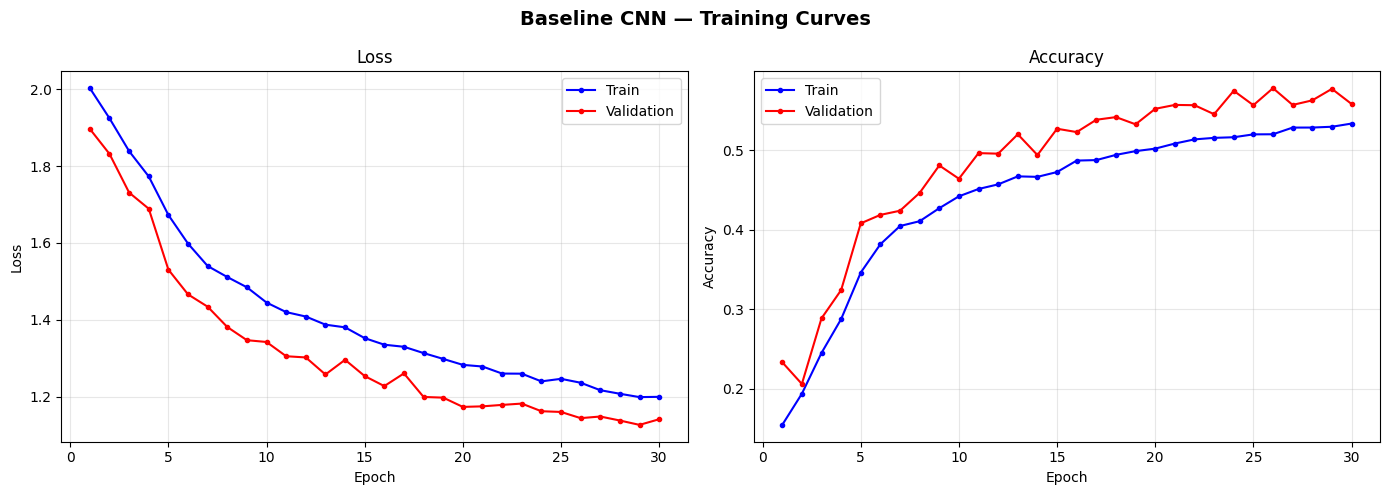

In [ ]:
# Plot training curves
plot_training_curves(
    baseline_history,
    title='Baseline CNN — Training Curves',
    save_path=FIGURES_DIR / 'baseline_cnn_curves.png',
)


  Baseline CNN — Evaluation Summary
  Accuracy      : 0.5766
  Weighted F1   : 0.5571
  Macro F1      : 0.5100
  Precision (w) : 0.5754
  Recall (w)    : 0.5766

Per-class classification report:
              precision    recall  f1-score   support

       angry       0.49      0.46      0.47       958
     disgust       0.23      0.73      0.35       111
        fear       0.45      0.13      0.20      1024
       happy       0.81      0.82      0.82      1774
     neutral       0.49      0.66      0.56      1233
         sad       0.48      0.42      0.45      1247
    surprise       0.64      0.84      0.72       831

    accuracy                           0.58      7178
   macro avg       0.51      0.58      0.51      7178
weighted avg       0.58      0.58      0.56      7178



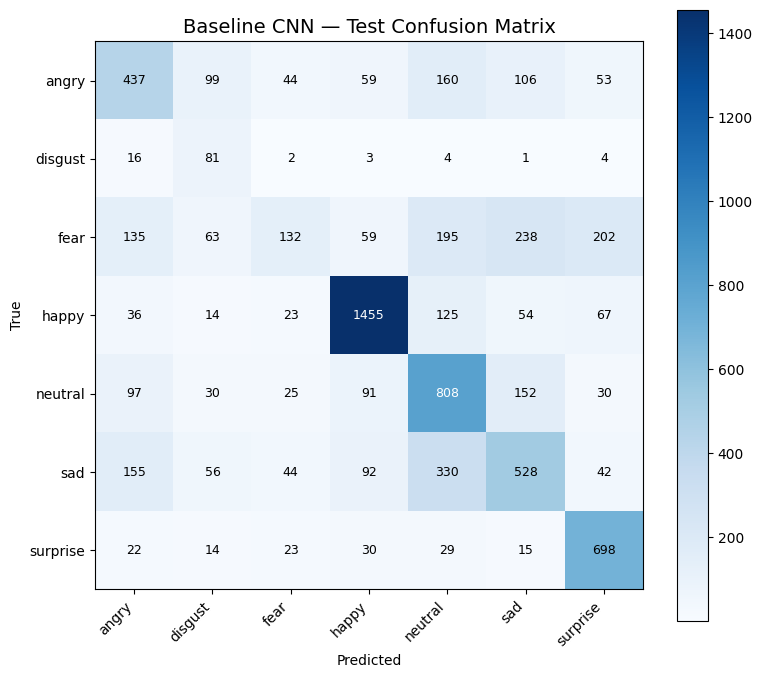

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/baseline_cnn_metrics.json


In [ ]:
# Evaluate on the test set
baseline_metrics, baseline_preds, baseline_labels = evaluate_model(
    baseline_model, baseline_test_loader, device, CLASS_NAMES,
    model_name='Baseline CNN',
)

# Best validation accuracy
baseline_metrics['val_acc'] = round(max(baseline_history['val_acc']), 4)

# Confusion matrix
plot_confusion_matrix(
    baseline_labels, baseline_preds, CLASS_NAMES,
    title='Baseline CNN — Test Confusion Matrix',
    save_path=FIGURES_DIR / 'baseline_cnn_confusion.png',
)

# Save table metrics
save_metrics(baseline_metrics, METRICS_DIR / 'baseline_cnn_metrics.json')

# Start result collection
all_results = [baseline_metrics]

## 10. Transfer Learning with ResNet-18

We test ResNet-18 in two settings: frozen feature extraction and partial fine-tuning. This shows whether ImageNet features transfer directly to low-resolution facial expressions, and whether unfreezing later layers helps.


In [ ]:
def create_resnet18(num_classes=7, freeze_backbone=True):
    """Create a ResNet-18 with a replaced FC head for emotion classification.

    Parameters
    ----------
    num_classes : int
        Number of output classes.
    freeze_backbone : bool
        If True, freeze all backbone parameters (feature extraction mode).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final classifier
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes),
    )

    return model

In [ ]:
# Build transfer-learning dataloaders
(tl_train_ds, tl_val_ds, tl_test_ds,
 tl_train_loader, tl_val_loader, tl_test_loader) = \
    create_datasets_and_loaders(
        tl_train_transform,
        tl_test_transform,
        batch_size=TL_BS,
        num_workers=NUM_WORKERS
    )

print(f"TL Train samples : {len(tl_train_ds)}")
print(f"TL Val samples   : {len(tl_val_ds)}")
print(f"TL Test samples  : {len(tl_test_ds)}")

imgs, lbls = next(iter(tl_train_loader))
print(f"Sample TL batch  : images {imgs.shape}, labels {lbls.shape}")

TL Train samples : 22967
TL Val samples   : 5742
TL Test samples  : 7178
Sample TL batch  : images torch.Size([64, 3, 224, 224]), labels torch.Size([64])


### Feature Extraction

In this setup, the ResNet backbone is frozen and only the new classification head is trained.


In [ ]:
# Feature extraction setup
FE_EPOCHS = 20
FE_LR = 1e-3

set_seed(42)
fe_model = create_resnet18(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)

trainable, total = count_parameters(fe_model)
print("ResNet-18 Feature Extraction")
print(f"  Trainable params : {trainable:,} / {total:,}")

fe_criterion = nn.CrossEntropyLoss(weight=class_weights)
fe_optimizer = optim.Adam(fe_model.fc.parameters(), lr=FE_LR)

fe_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    fe_optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

fe_history = train_model(
    fe_model, tl_train_loader, tl_val_loader,
    fe_criterion, fe_optimizer, fe_scheduler,
    epochs=FE_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / 'resnet18_feature_extract_best.pth',
    patience=PATIENCE,
    model_name='ResNet-18 (Feature Extraction)',
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 240MB/s]


ResNet-18 Feature Extraction
  Trainable params : 3,591 / 11,180,103

  Training: ResNet-18 (Feature Extraction)
  Epoch  1/20  |  Train Loss: 1.9487  Acc: 0.2275  |  Val Loss: 1.7203  Acc: 0.3701  |  LR: 0.001000
  Epoch  2/20  |  Train Loss: 1.8291  Acc: 0.2761  |  Val Loss: 1.6845  Acc: 0.3544  |  LR: 0.001000
  Epoch  3/20  |  Train Loss: 1.8100  Acc: 0.2890  |  Val Loss: 1.7004  Acc: 0.3865  |  LR: 0.001000
  Epoch  4/20  |  Train Loss: 1.7957  Acc: 0.2916  |  Val Loss: 1.6784  Acc: 0.3558  |  LR: 0.001000
  Epoch  5/20  |  Train Loss: 1.8013  Acc: 0.2864  |  Val Loss: 1.6997  Acc: 0.3833  |  LR: 0.001000
  Epoch  6/20  |  Train Loss: 1.8130  Acc: 0.2872  |  Val Loss: 1.6884  Acc: 0.3824  |  LR: 0.001000
  Epoch  7/20  |  Train Loss: 1.7927  Acc: 0.2968  |  Val Loss: 1.6756  Acc: 0.3959  |  LR: 0.001000
  Epoch  8/20  |  Train Loss: 1.8020  Acc: 0.2916  |  Val Loss: 1.6908  Acc: 0.3880  |  LR: 0.001000
  Epoch  9/20  |  Train Loss: 1.8089  Acc: 0.2884  |  Val Loss: 1.7158  Acc: 0.

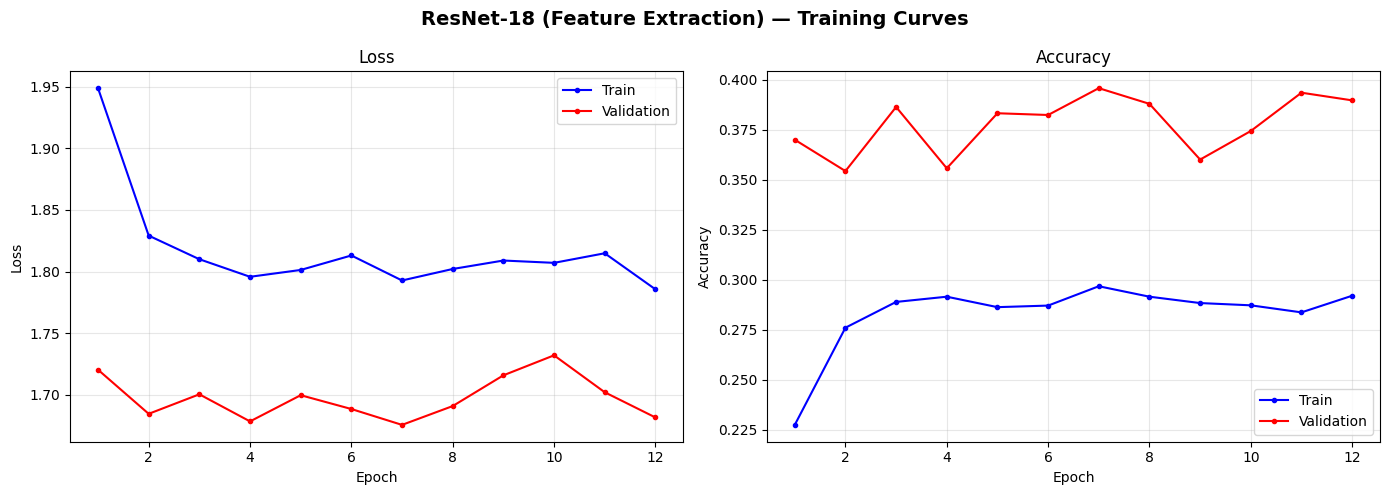


  ResNet-18 (Feature Extraction) — Evaluation Summary
  Accuracy      : 0.3924
  Weighted F1   : 0.3777
  Macro F1      : 0.3356
  Precision (w) : 0.3866
  Recall (w)    : 0.3924

Per-class classification report:
              precision    recall  f1-score   support

       angry       0.28      0.30      0.29       958
     disgust       0.09      0.19      0.12       111
        fear       0.25      0.20      0.22      1024
       happy       0.49      0.60      0.54      1774
     neutral       0.39      0.37      0.38      1233
         sad       0.41      0.18      0.25      1247
    surprise       0.47      0.67      0.55       831

    accuracy                           0.39      7178
   macro avg       0.34      0.36      0.34      7178
weighted avg       0.39      0.39      0.38      7178



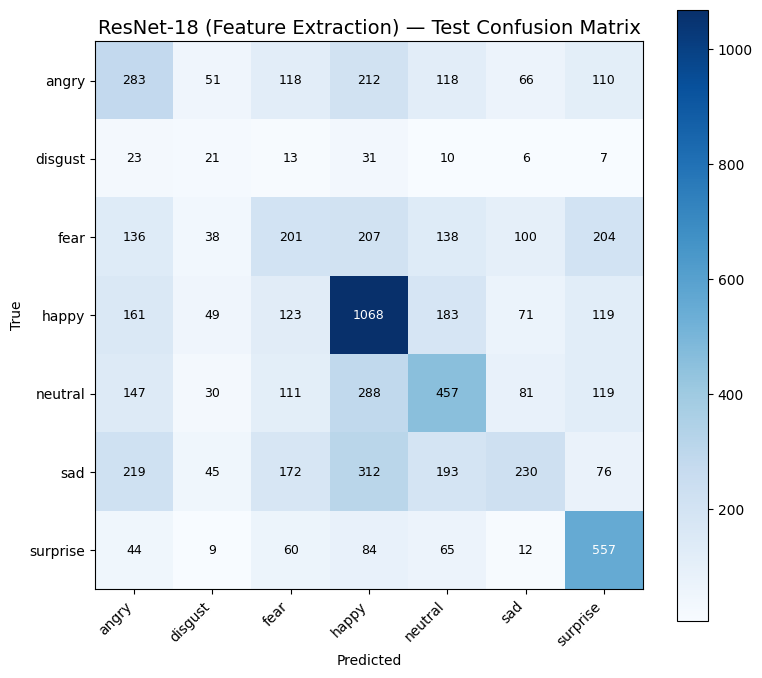

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/resnet18_fe_metrics.json


In [ ]:
# Evaluate feature extraction model
plot_training_curves(
    fe_history,
    title='ResNet-18 (Feature Extraction) — Training Curves',
    save_path=FIGURES_DIR / 'resnet18_fe_curves.png',
)

fe_metrics, fe_preds, fe_labels = evaluate_model(
    fe_model, tl_test_loader, device, CLASS_NAMES,
    model_name='ResNet-18 (Feature Extraction)',
)
fe_metrics['val_acc'] = round(max(fe_history['val_acc']), 4)

plot_confusion_matrix(
    fe_labels, fe_preds, CLASS_NAMES,
    title='ResNet-18 (Feature Extraction) — Test Confusion Matrix',
    save_path=FIGURES_DIR / 'resnet18_fe_confusion.png',
)

save_metrics(fe_metrics, METRICS_DIR / 'resnet18_fe_metrics.json')
all_results.append(fe_metrics)

### Fine-Tuning

For fine-tuning, `layer3`, `layer4`, and the classifier head are trainable. The backbone uses a smaller learning rate than the new head.


In [ ]:
# Fine-tuning setup
FT_EPOCHS       = 20
FT_LR_BACKBONE  = 1e-4
FT_LR_HEAD      = 1e-3

set_seed(42)
ft_model = create_resnet18(num_classes=NUM_CLASSES, freeze_backbone=False).to(device)

# Train only layer3, layer4, and fc
for name, param in ft_model.named_parameters():
    if not any(part in name for part in ['layer3', 'layer4', 'fc']):
        param.requires_grad = False

trainable, total = count_parameters(ft_model)
print(f"ResNet-18 Fine-Tuning")
print(f"  Trainable params : {trainable:,} / {total:,}")

# Differential learning rates
ft_optimizer = optim.Adam([
    {'params': ft_model.layer3.parameters(), 'lr': FT_LR_BACKBONE},
    {'params': ft_model.layer4.parameters(), 'lr': FT_LR_BACKBONE},
    {'params': ft_model.fc.parameters(),     'lr': FT_LR_HEAD},
])
ft_criterion = nn.CrossEntropyLoss(weight=class_weights)
ft_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    ft_optimizer, mode='min', factor=0.5, patience=3
)

ft_history = train_model(
    ft_model, tl_train_loader, tl_val_loader,
    ft_criterion, ft_optimizer, ft_scheduler,
    epochs=FT_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / 'resnet18_finetune_best.pth',
    patience=PATIENCE,
    model_name='ResNet-18 (Fine-Tuning)',
)

ResNet-18 Fine-Tuning
  Trainable params : 10,497,031 / 11,180,103

  Training: ResNet-18 (Fine-Tuning)
  Epoch  1/20  |  Train Loss: 1.5048  Acc: 0.4404  |  Val Loss: 1.2472  Acc: 0.5064  |  LR: 0.000100
  Epoch  2/20  |  Train Loss: 1.1675  Acc: 0.5578  |  Val Loss: 1.1070  Acc: 0.5759  |  LR: 0.000100
  Epoch  3/20  |  Train Loss: 1.0387  Acc: 0.6013  |  Val Loss: 1.0689  Acc: 0.6062  |  LR: 0.000100
  Epoch  4/20  |  Train Loss: 0.9414  Acc: 0.6324  |  Val Loss: 1.0782  Acc: 0.6041  |  LR: 0.000100
  Epoch  5/20  |  Train Loss: 0.8599  Acc: 0.6632  |  Val Loss: 1.1077  Acc: 0.6376  |  LR: 0.000100
  Epoch  6/20  |  Train Loss: 0.8002  Acc: 0.6842  |  Val Loss: 1.0621  Acc: 0.6162  |  LR: 0.000100
  Epoch  7/20  |  Train Loss: 0.7439  Acc: 0.7033  |  Val Loss: 1.1851  Acc: 0.6301  |  LR: 0.000100
  Epoch  8/20  |  Train Loss: 0.6886  Acc: 0.7269  |  Val Loss: 1.2344  Acc: 0.6472  |  LR: 0.000100
  Epoch  9/20  |  Train Loss: 0.6129  Acc: 0.7523  |  Val Loss: 1.1599  Acc: 0.6357  |  

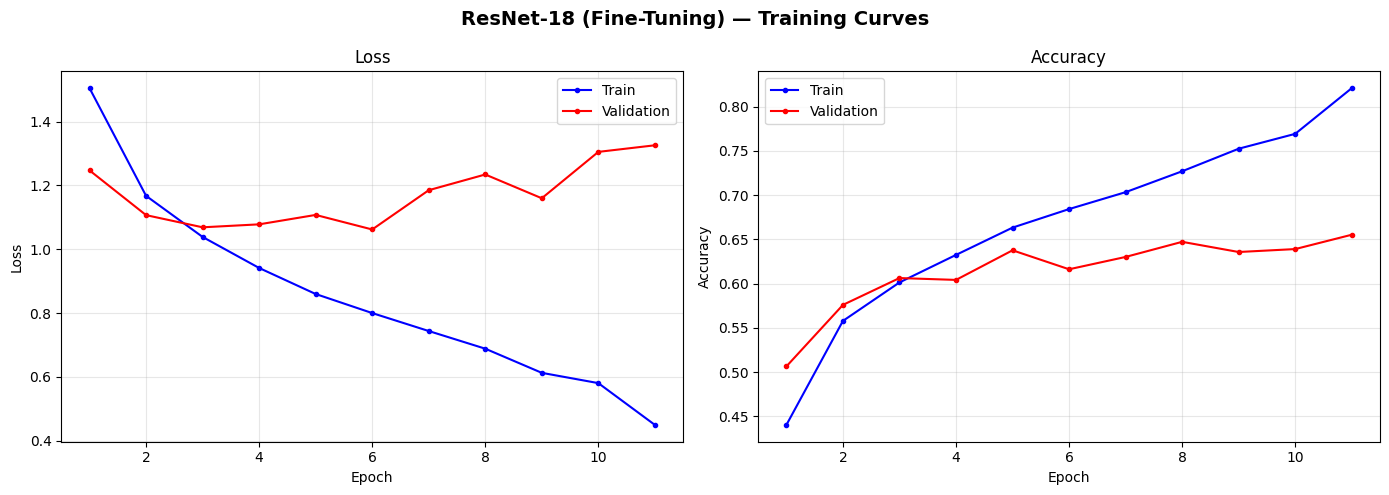


  ResNet-18 (Fine-Tuning) — Evaluation Summary
  Accuracy      : 0.6655
  Weighted F1   : 0.6654
  Macro F1      : 0.6547
  Precision (w) : 0.6711
  Recall (w)    : 0.6655

Per-class classification report:
              precision    recall  f1-score   support

       angry       0.53      0.64      0.58       958
     disgust       0.73      0.66      0.69       111
        fear       0.59      0.44      0.50      1024
       happy       0.90      0.85      0.87      1774
     neutral       0.61      0.61      0.61      1233
         sad       0.53      0.57      0.55      1247
    surprise       0.75      0.82      0.78       831

    accuracy                           0.67      7178
   macro avg       0.66      0.65      0.65      7178
weighted avg       0.67      0.67      0.67      7178



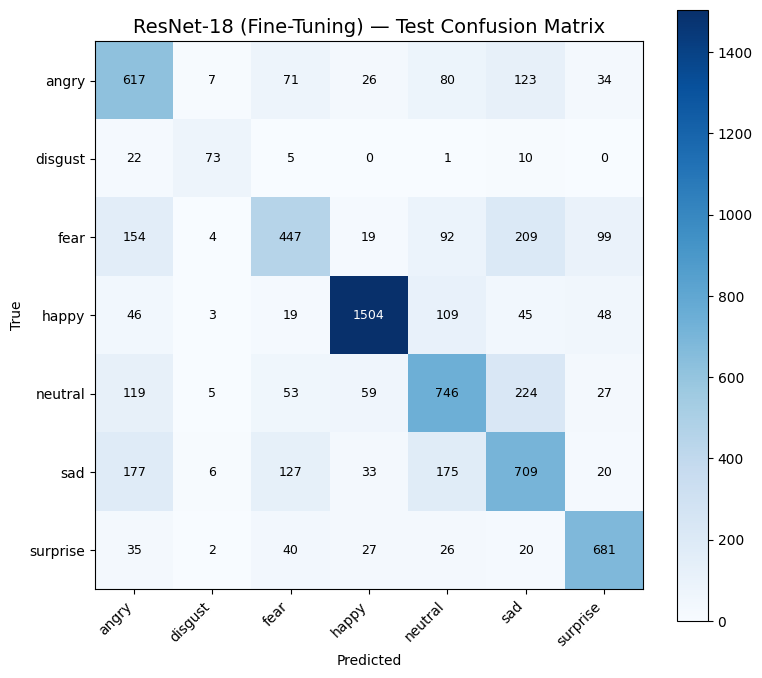

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/resnet18_ft_metrics.json


In [ ]:
# Evaluate fine-tuned model
plot_training_curves(
    ft_history,
    title='ResNet-18 (Fine-Tuning) — Training Curves',
    save_path=FIGURES_DIR / 'resnet18_ft_curves.png',
)

ft_metrics, ft_preds, ft_labels = evaluate_model(
    ft_model, tl_test_loader, device, CLASS_NAMES,
    model_name='ResNet-18 (Fine-Tuning)',
)
ft_metrics['val_acc'] = round(max(ft_history['val_acc']), 4)

plot_confusion_matrix(
    ft_labels, ft_preds, CLASS_NAMES,
    title='ResNet-18 (Fine-Tuning) — Test Confusion Matrix',
    save_path=FIGURES_DIR / 'resnet18_ft_confusion.png',
)

save_metrics(ft_metrics, METRICS_DIR / 'resnet18_ft_metrics.json')
all_results.append(ft_metrics)

## 11. Results Comparison

The table and chart below compare the baseline CNN, frozen ResNet-18, and fine-tuned ResNet-18 on the test set.


In [ ]:
# Build comparison table
comparison_df = pd.DataFrame(all_results)

col_order = ['model', 'val_acc', 'accuracy', 'weighted_f1', 'macro_f1', 'precision', 'recall']
comparison_df = comparison_df[[c for c in col_order if c in comparison_df.columns]]

comparison_df.columns = [c.replace('_', ' ').title() for c in comparison_df.columns]

print("\n" + "="*70)
print("  Model Comparison — Checkpoint 2")
print("="*70)
print(comparison_df.to_string(index=False))

# Save table
comparison_df.to_csv(METRICS_DIR / 'model_comparison.csv', index=False)
print(f"\nComparison saved → {METRICS_DIR / 'model_comparison.csv'}")


  Model Comparison — Checkpoint 2
                         Model  Val Acc  Accuracy  Weighted F1  Macro F1  Precision  Recall
                  Baseline CNN   0.5782    0.5766       0.5571    0.5100     0.5754  0.5766
ResNet-18 (Feature Extraction)   0.3959    0.3924       0.3777    0.3356     0.3866  0.3924
       ResNet-18 (Fine-Tuning)   0.6552    0.6655       0.6654    0.6547     0.6711  0.6655

Comparison saved → /content/drive/MyDrive/emotion_project/outputs/metrics/model_comparison.csv


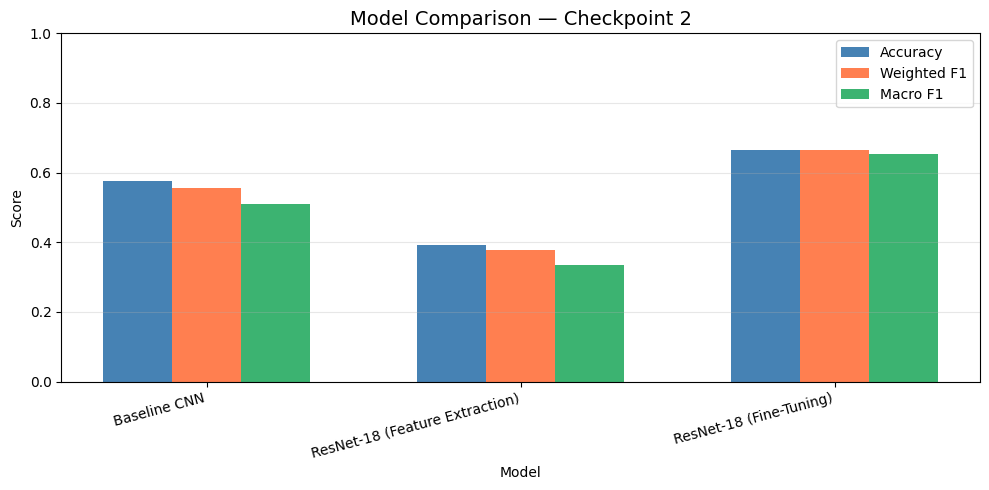

In [ ]:
# Comparison chart
fig, ax = plt.subplots(figsize=(10, 5))

models  = comparison_df['Model']
x       = np.arange(len(models))
width   = 0.22

ax.bar(x - width, comparison_df['Accuracy'],    width, label='Accuracy',    color='steelblue')
ax.bar(x,         comparison_df['Weighted F1'],  width, label='Weighted F1', color='coral')
ax.bar(x + width, comparison_df['Macro F1'],     width, label='Macro F1',    color='mediumseagreen')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Checkpoint 2', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Final Observations

### Most Confused Emotions

The fine-tuned ResNet-18 still confused several visually similar classes. The largest off-diagonal errors were mostly Neutral predicted as Sad, Fear predicted as Sad or Angry, and Sad predicted as Angry or Neutral. The baseline model showed the same general pattern, with Fear and Sad spread across several neighboring emotions.

### Class Imbalance Impact

FER-2013 is imbalanced, especially for Disgust. Using class-weighted cross-entropy helped keep the minority class from being ignored. In the fine-tuned ResNet-18 run, Disgust reached a much stronger F1 score than in the frozen feature-extraction model. Fear remained difficult even though it has more examples, which suggests that visual ambiguity matters in addition to class count.

### Baseline vs Transfer Learning

The baseline CNN reached about 57.66% test accuracy. Frozen ResNet-18 feature extraction performed worse at about 39.24%, but fine-tuning ResNet-18 improved to about 66.55% accuracy. This means the best transfer-learning setup was about 8.9 percentage points above the baseline.

### Feature Extraction vs Fine-Tuning

Feature extraction was not enough for this dataset. The frozen ImageNet features did not adapt well to 48x48 grayscale facial expressions. Partial fine-tuning raised accuracy from about 39.24% to 66.55%, with weighted F1 around 66.54% and macro F1 around 65.47%, so the extra compute was worth it.

### Overfitting Analysis

The fine-tuning curves show some overfitting. Training accuracy continued rising past 80%, while validation accuracy stayed around the mid-60% range. Validation loss started rising after the middle epochs, so early stopping was useful for keeping the best checkpoint.

### Next Steps for Final Submission

For the final version, the main next steps are to test stronger pretrained backbones such as EfficientNet and ConvNeXt, try cleaned-data training, add test-time augmentation, and evaluate simple soft-voting ensembles. It is also worth paying more attention to Fear, Sad, and Neutral because these were still the most difficult groups in the confusion matrices.
